#Tű a Szénakazalban

**A notebookot importáld be a Colab rendszerbe, majd abban dolgozz!**


**Versenyző neve:**

## Bevezetés

A nyelvi modellekkel szemben fontos elvárás, hogy egy hosszú szöveges állományban is megtaláljanak egy adott kérdéshez releváns információt. Képzeljük el például, hogy egy többszáz oldalas jogszabállyal, hogy egy bonyolult többezer soros kódbázissal kapcsolatban szeretnénk egy kérdést feltenni, amire a válasz megadható egy konkrét paragrafus, vagy függvény megtalálásával. Szeretnénk, ha a modell ezt megtalálná (a) a teljes dokumentum hosszától függetlenül és (b) függetlenül attól hogy a dokumentumon belül hol helyezkedik el az információ.

Ahhoz, hogy ezt a képességet szisztematikusan tesztelje, Greg Kamradt kidolgozott egy tesztet, ami [*Needle in a Haystack* (NIAH)](https://github.com/gkamradt/LLMTest_NeedleInAHaystack) vagyis tű a szénakazalban tesztként híresült el. A teszt lényege, hogy egy hosszú dokumentumba (a szénakazal) valahova elrejtünk valamilyen információt (a tű), majd felteszünk a modellnek egy kérdést, amire az elrejtett információ alapján tud csak helyesen válaszolni.

Ezt a feladatsort a tű a szénakazalban teszt inspirálta, lesznek szénakazlak (véletlen stringek) belsejében elrejtett tűk (üzenetek), de a problémának kicsit egyszerűsítettebb változataival fogunk foglalkozni.

## A részfeladatok

Ez a feladat több részfeladatból áll, aminek egy része pytorch, másik része Mistral API használatát igényli. A részfeladatok közül szabadon válogathattok, de javasoljuk, hogy kategóriánként nagyjából sorrendben haladjatok, mert így lettek a feladatok megírva.

### Pytorch feladatok (`55 + 30 x projekt`):
1. ` 5 pont` Számold ki a költségfüggvény értékét (pytorch)
1. `10 pont` Számold ki a false negative adatok valószínűséget (matek)
1. ` 5 pont` Javíts a tanító kódon (pytorch, algoritmusok)
1. ` 5 pont` Értékeld ki a modellt hosszabb bemeneteken (pytorch, matplotlib)
1. `10 pont` Ábrázold, hogy mire figyel az RNN (pytorch, gradiensek, matplotlib)
1. ` 5 pont` Próbálj ki más RNN architektúrákat (pytorch, architektúrák, matplotlib)
1. ` 5 pont` Megoldható-e a feladat konvolúciós hálózattal? (pytorch, konvolúció)
1. `10 pont` Implementálj konvolúciós hálózatot (pytorch, konvolúció)
1. `30 pont` **Szabadon értelmezhető miniprojekt** (Te találod ki, mit csinálsz)

### Mistral API feladatok (`35 + 30 x projekt`)
1. ` 5 pont` Tervezz természetes nyelvű "tű a szénakazalban" tesztet (tervezés)
1. `10 pont` Implementáld a megtervezett tesztet (Mistral API, matplotlib)
1. ` 5 pont` Tervezz kódolós "tű a szénakazalban" tesztet (tervezés)
1. `10 pont` Implementáld a megtervezett tesztet (Mistral API, matplotlib)
1. ` 5 pont` Mistral 7B és Mixtral 8x7B modellek összehasonlítása (Mistral API)
1. `30 pont` **Szabadon értelmezhető miniprojekt** (Te találod ki, mit csinálsz)



# Pytorch feladatok

A pytorch feladatokat a tű a szénakazalban teszt inspirálta, de néhány aspektusban attól eltér, egyszerűbb:
* **most mi tanítunk modelleket:** itt nem előre betanított modelleket fogunk tesztelni, hanem saját modelleket fogunk tanítani, egy direkt erre a célra létrehozott tanító adathalmazon.
* **bináris osztályozás:** a saját modelljeink nem generatív nyelvi modellek lesznek majd (mint amilyen a ChatGPT vagy a Mistral), hanem egy egyszerű bináris osztályozás problémát oldanak meg: a modell bemebete szöveg, kimenete egyetlen valószínűség: eldönti, hogy a bemeneti szénakazalban van-e tű, vagy sem.
* **bináris stringek:** azért, hogy a modelljeink minél egyszerűbbek lehessenek, a mi szövegeink bináris, 0/1 stringek lesznek.

## Az adatok, amikkel dolgozni fogunk

A lenti függvény létrehoz egy `TensorDataset` objektumot, amiben a bináris stringek lesznek, amikkel dolgozunk majd. A docstring leírja, hogy használható.

In [ ]:
# @title Adathalmaz definiálása

import torch
import numpy as np
from torch.utils.data import TensorDataset, DataLoader

def get_binary_dataset(num_datapoints : int,
                       needle_length : int=20,
                       haystack_length : int=20) -> TensorDataset:
  '''
  Creates a labelled dataset of `num_datapoints` binary sequences. Each sequence
  is of total length `needle_length + haystack_length`. Positive examples have
  a needle string of length `needle_length` embedded starting at a random
  location within the string, surrounded by random 0s and 1s. The needle itself
  is a binary string of alternating 1s and 0s. Negative examples are completely
  random bitstrings of length `needle_length + haystack_length`. They may
  contain a needle by chance, although the probability of this is small as the
  `needle_legth` increases.

  The returned dataset contains positive examples first, followed by negatives.
  When using minibatch-SGD, the dataset has to be shuffled before broken into
  minibatches.

  Attributes
  ----------
  num_datapoints : int
    Number of datapoints to be generated. Half of the datapoints will be
    positive, the rest negative. If `num_datapoints==1` then the dataset will
    contain a single positive example.
  needle_length : int
    Length of the needle string
  haystack_length : int
    Number of haystack bits in the sequence in addition to the needle sequence.

  Returns
  -------
  torch.utils.data.TensorDataset
    Pytorch dataset containing the strings and their binary labels.
  '''
  num_positives = num_datapoints - num_datapoints // 2
  y = np.array([[1.0]]*num_positives + [[0.0]]*(num_datapoints - num_positives))
  X = np.random.randint(2, size=(num_datapoints, needle_length + haystack_length))
  needle = np.array((needle_length//2)*[1.0, 0.0])
  for i in range(num_positives):
    j = np.random.randint(haystack_length)
    X[i, j:(j+needle_length)] = needle
  X = torch.tensor(X, dtype=torch.float)[:, :, None]
  y = torch.tensor(y)
  return TensorDataset(X, y)

Nézzük meg, hogy is néz ki ez az adathalmaz! Alább generálok $100$ pozitív és $100$ negatív mintát, mindegyik $40$ hosszúságú. Ez egy $200\times40$ méretű mátrixot eredményez, amit megjelenítek. A pozitív mintákban látható lesz az elhelyezett 20 karakter hosszúságú `10101010101010101010` "tű", véletlen helyen mindegyik szénakazalon (soron) belül.

*Megjegyzés:* Itt a `spy` függvényt használom, ami sparse, azaz ritka mátrixok ábrázolására való, amikben sok a nulla, és csak az érdekel, hogy hol vannak a nemnulla elemek.

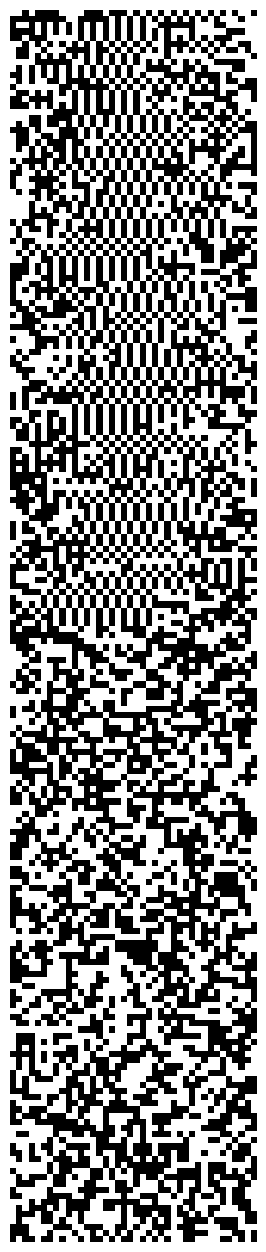

In [ ]:
# @title Minták kirajzolása
from matplotlib import pylab as plt

ds = get_binary_dataset(200,
                        needle_length=20,
                        haystack_length=20)

plt.figure(figsize=(4, 16))
plt.spy(ds.tensors[0][:, :, 0].numpy())
plt.axis('off');

## A legegyszerűbb RNN modell

Most egy egyszerű, RNN-alapú osztályozót fogunk építeni bináris sorozatok osztályozására. Az RNN-be tápláljuk a sorozatot, majd kinyerjük a rejtett állapot aktivációit a sorozat végén, végül lineáris transzformációt alkalmazunk az osztályozó kimenetének kiszámításához.

Egy RNN modul két kimenetet ad vissza, ahogy ezt a [dokumentáció](https://pytorch.org/docs/stable/generated/torch.nn.RNN.html) is elmagyarázza. Egy olyan rétegre is szükségünk lesz, amely kiválasztja a második kimenetet - a sorozat végén lévő rejtett állapot aktivációja -, majd átrendezi és átformálja (`flatten`), hogy az a lineáris réteg bemenete lehessen.

*Megjegyzés:* Egy további `sigmoid` alkalmazásával az osztályozó kimenete valószínűséggé alakítható, ahhoz hasonlóan, mint ahogy a `softmax` is működik. Nem fogjuk a sigmoidot a hálózat részévé tenni, mivel így a tanulás numerikailag stabilabb lesz.

In [ ]:
# @title RNN Osztályozó definíciója

from torch.nn import RNN, Linear, Sequential

class extract_last_cell(torch.nn.Module):
  '''Pytorch module which extracts and flattens the last hidden state of an RNN.
  '''
  def forward(self,x):
    _ , out = x
    return out.permute(1,0,2).flatten(start_dim=1)

def get_basic_RNN_classifier():
  return Sequential(
    RNN(input_size=1, hidden_size=20, num_layers=2, batch_first=True),
    extract_last_cell(),
    Linear(in_features = 20*2, out_features=1)
  )

## 1\. Részfeladat: Számold ki a költségfüggvény értékét

Számold ki a tanítatlan, véletlen súlyokkal inicializált hálózat logaritmikus hibáját (vagyis a cross entropy loss-t vagy log loss-t) a fent definiált adathalmaz ból származó minibatch-eken.

*Tippek:*
* használhatod a [`pytorch/utils.data.DataLoader`](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader) osztályt hogy minibatch-eket mintavételezz az adatokból.
* és/vagy hozzáférhetsz a `TensorDataset` tartalmához közvetlenül is a `tensors` attribútum használatával.
* használd a [`torch.nn.BCEWithLogitsLoss`](https://pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html) osztályt vagy a [`torch.nn.functional.binary_cross_entropy_with_logits`](https://pytorch.org/docs/stable/nn.functional.html) függvényt. Javaslom, hogy olvasd át a dokumentációt.

*5 pont*

### A megoldásod

Használd ezt a szövegcellát és a lenti kód cellát, vagy adj hozzá további cellákat, ha szükségesnek tartod.

## 2\. Részfeladat: False negative valószínűség számolás

Mint a dokumentáció is említi, van elenyésző valószínűsége annak, hogy egy negatív adatpontban is épp előfordul a tű szekvencia. Ilyenkor ezt az adatpontot false negative-nak nevezhetjük, mert bár van benne tű, negatív cimkével szerepel.

Legyen a tű hossza $k$, és a teljes szekvencia hossza $k+l$. Számold ki annak a valószínűségét hogy egy negatív minta ($k+l$ hosszú bináris szekvencia, ahol a $0$ és $1$ ugyanakkora valószínűséggel szerepel) valójában pozitív, azaz tartalmazza a $k$-hosszúságú $010101\ldots01$ szekveciát. Írd le, hogy hogy gondolkoztál. Megoldásod lehet egy formula, vagy akár egy python függvény, aminek paraméterei $k$ és $l$.

*Tipp:*
* Ha ismered, használj LaTeX kifejezéseket, amiket dollár jelek közé írhatsz

*10 pont*

### A megoldásod

## A tanítókód

A lenti tanító kód megírásához az `ignite` frameworköt használtuk. Ezt először is installáljuk. a python modult. A kód maga elég hosszú, de valójában nagyon egyszerű. A kód alatt annak néhány komponensét elmagyarázzuk.


In [ ]:
# @title `torch-ignite` installálása
!pip install pytorch-ignite

In [ ]:
# @title Eredeti tanítókód
from ignite.engine import Events, create_supervised_trainer, create_supervised_evaluator
from ignite.metrics import Accuracy, Loss

def fit_model_basic(model : torch.nn.Module,
                    training_dataset : torch.utils.data.Dataset,
                    test_dataset : torch.utils.data.Dataset) -> torch.nn.Module:
  '''Fits a pytorch model to the training dataset using stochastic gradient
  descent and tracks progress on a test set.

  Arguments
  ---------
  model : pytorch.nn.Module
    pytorch model that can be evaluated on input tensor in the dataset, and
    returns a tensor that matches the shape of the output tensor.
  training_dataset : pytorch.util.data.Dataset
    used to train the model
  test_dataset : pytorch.util.data.Dataset
    used to evaluate the performance of the model at the end of each epoch

  Retuns
  ------
  pytorch.nn.Module
    the model after training
  '''

  train_loader = DataLoader(
      training_dataset,
      batch_size=100,
      shuffle=True
  )
  val_loader = DataLoader(
      test_dataset,
      batch_size=1000,
      shuffle=False,
  )

  optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
  criterion = torch.nn.BCEWithLogitsLoss()

  trainer = create_supervised_trainer(model, optimizer, criterion)

  def thresholded_output_transform(output):
      y_pred, y = output
      y_pred = torch.heaviside(y_pred, values=torch.zeros(1))
      return y_pred, y

  val_metrics = {
      "accuracy": Accuracy(thresholded_output_transform),
      "bce": Loss(criterion)
  }
  evaluator = create_supervised_evaluator(model, metrics=val_metrics)

  @trainer.on(Events.ITERATION_COMPLETED(every=10))
  def log_training_loss(trainer):
      print(f"Epoch[{trainer.state.epoch}] Loss: {trainer.state.output:.2f}")

  @trainer.on(Events.EPOCH_COMPLETED)
  def log_training_results(trainer):
      evaluator.run(train_loader)
      metrics = evaluator.state.metrics
      print(f"Training Results - Epoch: {trainer.state.epoch}  Avg accuracy: {metrics['accuracy']:.2f} Avg loss: {metrics['bce']:.2f}")

  @trainer.on(Events.EPOCH_COMPLETED)
  def log_validation_results(trainer):
      evaluator.run(val_loader)
      metrics = evaluator.state.metrics
      print(f"Validation Results - Epoch: {trainer.state.epoch}  Avg accuracy: {metrics['accuracy']:.2f} Avg loss: {metrics['bce']:.2f}")

  trainer.run(train_loader, max_epochs=5)

  return model

A fenti kód hosszúnak és bonyolultnak tűnhet, de ez azért van, mert szeretnénk, hogy az ignite részletesen naplózza a tanulási folyamat előrehaladását.

Az Ignite Python dekorátorokat használ (mint például a `@trainer.on(Events.EPOCH_COMPLETED))`. Az Ignite-ban ezeket a dekorátorokat arra használják, hogy olyan függvényeket regisztráljanak, amelyeket a tanulás során különböző események bekövetkezésekor hívnak meg. Például a `@trainer.on(Events.ITERATION_COMPLETED(every=10))` azt mondja az ignite-nak, hogy hajtsa végre az alatta lévő függvényt minden 10. iteráció befejezésekor.

A fenti kód nagyrészt az [ignite dokumentációban](https://pytorch-ignite.ai/tutorials/beginner/01-getting-started/) is szereplő példa kód adaptációja, részletekben most nem kell megérteni.

Akkor csapjunk bele a lecsóba és használjuk a tanulási ciklusunkat arra, hogy egy osztályozót tanítsunk a létrehozott bináris adathalmazon:

In [ ]:
# @title Első próbálkozás tanításra

ds_train = get_binary_dataset(5000, needle_length=10, haystack_length=10)
ds_test = get_binary_dataset(1000, needle_length=10, haystack_length=10)
rnn_classifier = get_basic_RNN_classifier()

fit_model_basic(rnn_classifier, ds_train, ds_test)

Epoch[1] Loss: 0.69
Epoch[1] Loss: 0.69
Epoch[1] Loss: 0.69
Epoch[1] Loss: 0.69
Epoch[1] Loss: 0.70
Training Results - Epoch: 1  Avg accuracy: 0.50 Avg loss: 0.69
Validation Results - Epoch: 1  Avg accuracy: 0.50 Avg loss: 0.69
Epoch[2] Loss: 0.69
Epoch[2] Loss: 0.69
Epoch[2] Loss: 0.69
Epoch[2] Loss: 0.70
Epoch[2] Loss: 0.70
Training Results - Epoch: 2  Avg accuracy: 0.51 Avg loss: 0.69
Validation Results - Epoch: 2  Avg accuracy: 0.50 Avg loss: 0.69
Epoch[3] Loss: 0.69
Epoch[3] Loss: 0.69
Epoch[3] Loss: 0.69
Epoch[3] Loss: 0.70
Epoch[3] Loss: 0.69
Training Results - Epoch: 3  Avg accuracy: 0.51 Avg loss: 0.69
Validation Results - Epoch: 3  Avg accuracy: 0.50 Avg loss: 0.69
Epoch[4] Loss: 0.70
Epoch[4] Loss: 0.69
Epoch[4] Loss: 0.69
Epoch[4] Loss: 0.70
Epoch[4] Loss: 0.69
Training Results - Epoch: 4  Avg accuracy: 0.52 Avg loss: 0.69
Validation Results - Epoch: 4  Avg accuracy: 0.51 Avg loss: 0.69
Epoch[5] Loss: 0.69
Epoch[5] Loss: 0.69
Epoch[5] Loss: 0.69
Epoch[5] Loss: 0.69
Epoch[5]

Sequential(
  (0): RNN(1, 20, num_layers=2, batch_first=True)
  (1): extract_last_cell()
  (2): Linear(in_features=40, out_features=1, bias=True)
)

## 3\. Részfeladat: Javítsunk a tanítókódon

Hát, úgy látszik hogy a tanító függvényünk nem túl sikeres, hiszen a tanítás végére is csak alig több, mint 50%os pontosságot ér el, tehát lényegében semmivel nem jobb annál, mint ha pénzfeldobással tippelgetnénk.

Kis változtatásokkal viszont 90%+ feletti eredményt is el lehet érni.

Javíts a tanító kódon. A feladat alá bemásoltuk ugyanazt a függvényt mint az előbb, `fit_model_improved` névvel. A következő feladatokban majd ezt a függvényt fogod használni. Végezz rajta minimális változtatásokat, hogy a tanítás sikeresebb legyen.
* Adj a függvényhez extra argumentumokat, amikkel a tanítás fontos paramétereit (mint például a learning rate) lehet állítani
* Kicserélhetsz komponenseket, például választhatsz más optimalizáló algoritmust
* Dokumentáld a változtatásaidat, és hogy milyen módszerrel találtál jobb paramétereket.
* Demonstráld, hogy az új verzió jobban működik

*5 pont*


### A megoldásod

Írd át a lenti kód cella tartalmát, és adj hozzá további kód és szöveges cellákat.

In [ ]:
from ignite.engine import Events, create_supervised_trainer, create_supervised_evaluator
from ignite.metrics import Accuracy, Loss

def fit_model_improved(model : torch.nn.Module,
                    training_dataset : torch.utils.data.Dataset,
                    test_dataset : torch.utils.data.Dataset) -> torch.nn.Module:
  '''Fits a pytorch model to the training dataset using stochastic gradient
  descent and tracks progress on a test set.

  Arguments
  ---------
  model : pytorch.nn.Module
    pytorch model that can be evaluated on input tensor in the dataset, and
    returns a tensor that matches the shape of the output tensor.
  training_dataset : pytorch.util.data.Dataset
    used to train the model
  test_dataset : pytorch.util.data.Dataset
    used to evaluate the performance of the model at the end of each epoch

  Retuns
  ------
  pytorch.nn.Module
    the model after training
  '''

  train_loader = DataLoader(
      training_dataset,
      batch_size=100,
      shuffle=True
  )
  val_loader = DataLoader(
      test_dataset,
      batch_size=1000,
      shuffle=False,
  )

  optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
  criterion = torch.nn.BCEWithLogitsLoss()

  trainer = create_supervised_trainer(model, optimizer, criterion)

  def thresholded_output_transform(output):
      y_pred, y = output
      y_pred = torch.heaviside(y_pred, values=torch.zeros(1))
      return y_pred, y

  val_metrics = {
      "accuracy": Accuracy(thresholded_output_transform),
      "bce": Loss(criterion)
  }
  evaluator = create_supervised_evaluator(model, metrics=val_metrics)

  @trainer.on(Events.ITERATION_COMPLETED(every=10))
  def log_training_loss(trainer):
      print(f"Epoch[{trainer.state.epoch}] Loss: {trainer.state.output:.2f}")

  @trainer.on(Events.EPOCH_COMPLETED)
  def log_training_results(trainer):
      evaluator.run(train_loader)
      metrics = evaluator.state.metrics
      print(f"Training Results - Epoch: {trainer.state.epoch}  Avg accuracy: {metrics['accuracy']:.2f} Avg loss: {metrics['bce']:.2f}")

  @trainer.on(Events.EPOCH_COMPLETED)
  def log_validation_results(trainer):
      evaluator.run(val_loader)
      metrics = evaluator.state.metrics
      print(f"Validation Results - Epoch: {trainer.state.epoch}  Avg accuracy: {metrics['accuracy']:.2f} Avg loss: {metrics['bce']:.2f}")

  trainer.run(train_loader, max_epochs=5)

  return model

## 4\. Részfeladat: Értékeld ki a modellt hosszabb szekvenciákon

A fenti modellünket fix hosszúságú stringekkel tanítottuk, de egy RNN képes bármilyen hosszúságú bemenetet is feldolgozni.
* Próbáld ki hogy a sikeresen betanított model a tanító adatoknál hosszabb teszt szekvenciákon is sikeresen megtalálja-e a tűt?
* Az eredményeidet dokumentáld egy ábrával, és szövegesen is (röviden, 1-2 mondatban) értékeld.

*5 pont*

### A megoldásod

## 5\. Részfeladat: Próbálj ki más RNN architektúrákat

Próbálj ki a felkészítőn is említett más, gyakran használt RNN architektúrákat. Hasonlítsd össze egy ábrán, hogy ezek hogy teljesítenek, főleg a 4. Részfeladatban vizsgált hosszabb szekvenciákon. Értelmezd az eredményeket, és adj rövid (1-3 mondatos) magyarázatot.

*5 pont*

### A megoldásod

## 6\. Részfeladat: Illusztráld mire figyel a modell

Ebben a feladatrészben szeretnénk megérteni, hogy a modell a bemenetének melyik része alapján hozza meg a döntését. Ezt a problémát szokás attribúciónak is nevezni.

RNN-ek esetén a kimenetek bemenetek szerinti deriváltja, illetve azok nagysága tud erről információt szolgáltatni. Ezt a módszert használja [ez a distill cikk is](https://distill.pub/2019/memorization-in-rnns/), illetve előkerült ez a téma a felkészítőn, illetve [Feri jegyzeteiben is](https://hackmd.io/QrkitKUITGySbLAzkakzYw), ahol a vanishing gradients problémát illusztrálja.

* számold ki a modell kimenetének a bemenetek szerinti gradiensét
* ábrázold ezt úgy, hogy abból látható legyen, hogy a modell melyik bemenetekre figyel
* a többi részfeladataid megoldását felhasználva hasonlíts össze két szituációt (mondjuk két modellt, vagy különböző hosszúságú bemeneteket)
* vonj le konklúziót, írd le, hogy mit tapasztalsz (3-5 mondatban).

**Tipp:**
* a feladat megoldható legfeljebb 5-10 sor pytorch kóddal.

*10 pont*

### A megoldásod

## 7\. Részfeladat: Megoldható-e konvolúcióval?

Érvelj arról 3-5 mondatban, hogy megoldható-e szerinted a feladat konvolúciós hálózattal.
* Mekkora, milyen felépítésű konvolúciós hálózatra lenne szükség? Hány réteg, hány filter, mekkora filterek, stride illetve padding kell-e.
* Milyen pytorch rétegeket használnál?
* Mit vársz, jobban vagy rosszabban működik-e majd, mint egy RNN?

*5 pont*

### A megoldásod

## 8\. Részfeladat: Taníts konvolúciós hálózatot

Az előző részfeladatban is leírt megfigyelések alapján implementálj és taníts egy CNNt, majd értékeld ki az RNN-ekhez hasonlítva. Dokumentáld, hogy mit tapasztaltál (2-4 mondatban).

*Tippek*:
* mivel nem képekkel dolgozunk, most más pytorch rétegek lehetnek hasznosak, mint korábban láttuk. Érdemes jó alaposan szétnézni a [konvolúciós](https://pytorch.org/docs/stable/nn.html#convolution-layers) és az [adaptive pooling](https://pytorch.org/docs/stable/nn.html#pooling-layers) rétegek közt. Illetve lehet hogy olyan utility függvények is
* a dokumentáció olvasgatása segít abban is, hogy a tenzorok dimenziója/alakja stimmeljen. Hasznos utility rétegek, mint pl a `nn.Flatten` vagy `nn.Unflatten` is hasznosak lehetnek.
* ne bonyolítsd túl, ez egy egyszerű feladat, a legminimálisabb megoldásra jár a maximum pont.

*10 pont*

### A megoldásod

## 9. pytorch miniprojekt: Önálló exploráció

Ha a többi részfeladatot nagyrészt megoldottad, most rád bízzuk, hogy milyen kiegészítéseket szertnél még implementálni a témával kapcsolatban.
Itt van néhány példa:
* Adatok bonyolítása: mondjuk nem-bináris, diszkrét ábécéből húzott mintá, vagy multiclass (többféle tű)
* több komponensű tű ahol mondjuk egyszerre két substring jelenlétét kell detektálni.
* Pointer Network szerűség: ne csak azt mondd meg, hogy van-e tű, hanem hogy mi a kezdőpozíciója.
* Transzformer architektúra implementálása
* Generatív vagy sequence-to-sequence modell
* Tű a szénakazalban computer vision edition

Minden miniprojektért (többet is adhadsz be, csak ezek jól különüljenek el) max *30 pont* jár. Egy 30 pontos projekt jellemzői:
* **motiváció és kreativitás:** érdekes kreatív projekt, jó motiváció, hipotézisek-kérdések-célok egyértelmű leírása, referenciák az irodalomra, ahol releváns
* **implementáció:** nemtriviális munka ami demonstrálja a technikai felkészültséget, helyes implementáció, jó eszközválasztás, kompakt és olvasható kód
* **kiértékelés és konklúziók:** fair és részletes kiértékelés, ábrák kiváló használata (feliratok, címkék, stb), tömör de célratörő konklúzió.

*30 pont/miniprojekt*

# Mistral API feladatok

Ezekben a feladatokban a Mistral AI nyelvi modelljeit fogjátok tesztelni az API használatával, különböző, általatok megtervezett Needle in a Haystack (NIAH) teszttel.

## A Mistral API tesztelése

A verseny előtt megkértünk titeket, hogy szerezzetek API kulcsot a Mistraltól, és adjátok hozzá a colab-hoz. Ha ezt megtettétek, alábbi kódnak le kell futnia. Ebből a kódból az is látszik, hogy hogy lehet a modellel társalogni az API (application programming interface) használatával. Az API dokumentációt [itt](https://docs.mistral.ai/capabilities/completion/) találjátok.

In [ ]:
!pip install mistralai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.5/142.5 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 6.3 MB/s eta 0:00:00


In [ ]:
from mistralai.client import MistralClient
from mistralai.models.chat_completion import ChatMessage
from google.colab import userdata

model = 'open-mistral-7b'
api_key = userdata.get('MISTRAL_API_KEY')
client = MistralClient(api_key=api_key)

messages = [
    ChatMessage(role="user", content="What is the best French cheese?")
]

# No streaming
chat_response = client.chat(
    model=model,
    messages=messages,
)

print(chat_response.choices[0].message.content)

The "best" French cheese can be quite subjective as it depends on personal taste. However, some of the most famous and widely appreciated French cheeses include:

1. Roquefort: A blue cheese made from sheep's milk. It's known for its strong, pungent flavor and crumbly texture.

2. Camembert de Normandie: A soft, creamy cow's milk cheese with a white rind. It's often served at room temperature and has a mild, earthy flavor.

3. Brie de Meaux: Another soft, creamy cow's milk cheese, but with a smooth, spreadable texture. It has a mild, slightly nutty flavor.

4. Comté: A hard, nutty-flavored cheese made from unpasteurized cow's milk. It's often used in cooking and on sandwiches.

5. Reblochon: A soft, washed-rind cow's milk cheese from the Rhône-Alpes region. It's often used in dishes like fondue and tartiflette.

6. Munster: A soft, smelly cheese with a washed rind. It's known for its strong, spicy flavor.

7. Époisses de Bourgogne: A soft, smelly cheese with a washed rind. It's known f

## 1\. Részfeladat: Tervezz NIAH tesztet

Tervezz egy egyszerűsített tű a szénakazalban (NIAH) tesztet ami a `Mistral open 7B` modell természetes (angol) nyelvi képességeit teszteli. Ebben a tesztben viszonylag hosszú angol szövegekbe beszúrunk valamilyen rövid információt, majd felteszünk a modellnek egy kérdést amit a beszúrt információ alapján tud helyesen megválaszolni. Tervezd meg minél precízebben, hogy milyen szöveget fogsz használni, hogy fogod az APIt használni, hogy fogod kiértékelni az eredményeket, milyen teljesítményt vársz tőle. Mindezt 5-10 mondatban dokumentáld. A tökéletes megoldás tömör specifikáció, ami alapján minél pontosabban reprodukálható-elvégezhető a teszt.

*Tippek:*
* a [NIAH github repository](https://github.com/gkamradt/LLMTest_NeedleInAHaystack) egy az egyben használata nem megengedett, de adhat ötleteket a feladatok megoldásához.
* a [torchtext](https://pytorch.org/text/stable/index.html) library többféle könnyen hozzáférhető szöveges korpuszt tartalmaz.

*5 pont*

### A megoldásod

Használj szöveges cellát.

## 2\. Részfeladat: Implementáld a tesztet

Az előző részfeladatban megtervezett tesztet most implementáld, a Mistral API használatával. A kiértékelés eredményéről ideális esetben készíts ábrát is, és pár mondatban dokumentáld a megoldásod, valamint értékeld az eredményeket.

* A konzisztencia érdekében használd a Mistral 7B open source modellt!
* A bemeneti tokenek számát tartsd üzenetenként kb. 1000 token alatt, és ne használj összesen nagyságrendileg több, mint 10,000,000 tokent.

*10 pont*

### A megoldásod

Használj kód és szöveges cellákat!

## 3\. Részfeladat: Tervezz kódolós NIAH tesztet

Most hasonlóan az 1. részfeladathoz, tervezz meg egy NIAH tesztet, viszont most az angol nyelvi készségek helyett teszteld a kódolási/formális nyelvekhez kötődő képességeket. Tehát használj most programozási nyelvi adatokat, vagy algoritmikusan generált formális nyelveket. Dokumentáld az első részfeladathoz hasonlóan.

*5 pont*

### A megoldásod

## 4\. Részfeladat: Implementáld a tesztet

Az előző részfeladatban megtervezett kódolós NIAH tesztet most implementáld, a Mistral API használatával. A kiértékelés eredményéről ideális esetben készíts ábrát is, és pár mondatban dokumentáld a megoldásod, valamint értékeld az eredményeket.

* A konzisztencia érdekében most is használd a Mistral 7B open source modellt!
* A bemeneti tokenek számát tartsd továbbra is kb. 1000 token alatt, és ne használj összesen nagyságrendileg több, mint 10,000,000 tokent.

*10 pont*

### A megoldásod

## 5\. Részfeladat:

Hasonlítsd össze a Mistral 7B és Mixtral 8x7B open source modelleket a NIAH teszteken. Írj 3-5 sorban az eredményekről.

*5 pont*

## A megoldásod

## 6\. Mistral miniprojekt: Önálló exploráció

Ha a többi Mistralos részfeladatot nagyrészt megoldottad, most rád bízzuk, hogy milyen kiegészítéseket szeretnél még implementálni a témával kapcsolatban.
Itt van néhány példa:
* A teszt bonyolítása: mondjuk két tű van, amiket kombinálni kell, hogy a jó megoldás kijöjjön
* A Mistral API embedding endpontjának használata valamilyen kreatív módon, a tű a szénakazalban kontextusban.
* C++ kódban szintaxishibák sikeres, vagy sikertelen detektálása a kód hosszának, és a hiba pozíciójának függvényében.

Minden miniprojektért (többet is adhadsz be, csak ezek jól különüljenek el) max *30 pont* jár. Egy 30 pontos projekt jellemzői:
* **motiváció és kreativitás:** érdekes kreatív projekt, jó motiváció, hipotézisek-kérdések-célok egyértelmű leírása, referenciák az irodalomra, ahol releváns
* **implementáció:** nemtriviális munka ami demonstrálja a technikai felkészültséget, helyes implementáció, jó eszközválasztás, kompakt és olvasható kód
* **kiértékelés és konklúziók:** fair és részletes kiértékelés, ábrák kiváló használata (feliratok, címkék, stb), tömör de célratörő konklúzió.

*30 pont/miniprojekt*